# Margin Ascent Selector

`u = e_c` asks *what supports class c*. Often the useful question is *what
supports c against the classes it is actually competing with* everything
that helps c and its rivals equally is not evidence for the decision.

```
u = e_c - softmax_Rk(z / tau_m)
```

`R_k` = the `k-1` highest-logit non-target classes.

A contrastive selector like this was tried before by hand. Three things were
wrong with it, and all three are construction problems rather than measurement
problems.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
torch.set_num_threads(4)
pd.set_option('display.width', 160)

from spx import load_bundle, load_imagenette
from spx.data import IMAGENETTE_NAMES
from spx.dossier import show_maps, summary_table

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bundle = load_bundle('resnet50', device)

x_np, y_np, _ = load_imagenette(n=4, res=224, seed=0)
X = torch.as_tensor(x_np, device=device)
Y = torch.as_tensor(y_np, device=device)
titles = [IMAGENETTE_NAMES[int(v)] for v in y_np]
titles

['gas pump', 'chain saw', 'gas pump', 'French horn']

## 1. The old selector was not the gradient of anything

The previous version was written down directly: `+1` on the target, `-1/(k-1)`
on the top rivals. But every faithfulness metric is defined as agreement between
the map and the change in **some score**, and a hand-picked selector has no
score attached so there was nothing to check it against.

It turns out that selector *is* the gradient of something, namely a smooth
top-k logit margin:

```
m_c = z_c - tau_m * LSE_{j in Rk} (z_j / tau_m)
```

Writing it this way costs nothing and gives the method a functional.

In [2]:
from spx.selectors import margin_score, margin_selector

torch.manual_seed(0)
z = torch.randn(4, 20, dtype=torch.float64, requires_grad=True)
tgt = torch.tensor([3, 3, 3, 3])

rows = []
for tau in (0.5, 1.0, 4.0, float('inf')):
    # freeze the rival set so the score is a fixed functional
    masked = z.detach().masked_fill(torch.nn.functional.one_hot(tgt, 20).bool(), -np.inf)
    idx = masked.topk(7, dim=-1).indices

    s = margin_score(z, tgt, k=8, tau_m=tau, rival_idx=idx)
    g, = torch.autograd.grad(s.sum(), z, retain_graph=True)
    u = margin_selector(z.detach(), tgt, k=8, tau_m=tau)
    rows.append({'tau_m': tau, 'max |dm/dz - u|': float((g - u).abs().max())})
pd.DataFrame(rows)

,tau_m,max |dm/dz - u|
0,0.5,2.220446e-16
1,1.0,1.110223e-16
2,4.0,8.326673e-17
3,inf,0.000000e+00


## 2. Three hand-designed variants were one knob

The previous work compared three rival weightings and picked the best. They are
the same operator at three temperatures:

| `tau_m` | rival weights | old name |
|---|---|---|
| `-> 0` | all on the strongest rival | (not tried) |
| `= 1` | proportional to the rivals' probabilities | "proportional" |
| `-> inf` | uniform over the top `k-1` | "hard uniform" |

Once it is a temperature you can sweep it, and the sweep finds an **interior**
optimum at `tau_m ~ 1-2` better than either endpoint, and one of those
endpoints is what the three-way comparison had selected.

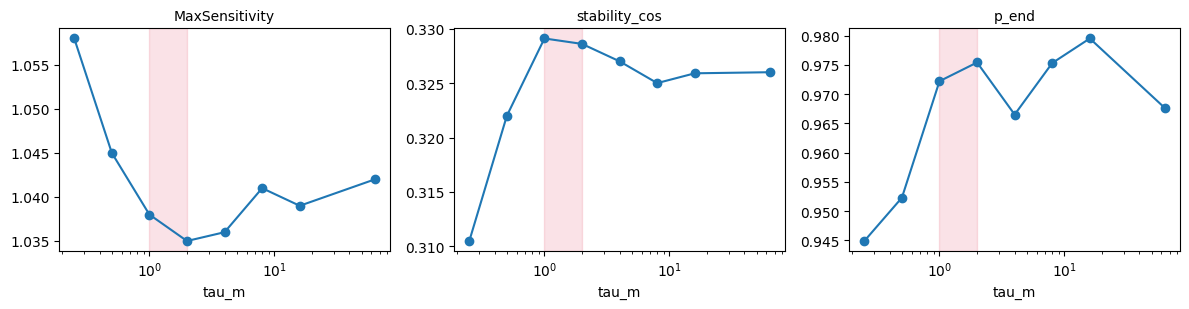

,tau_m,MaxSensitivity,stability_cos,p_end
0,0.25,1.058,0.3105,0.9449
1,0.50,1.045,0.3220,0.9523
2,1.00,1.038,0.3291,0.9722
3,2.00,1.035,0.3286,0.9754
4,4.00,1.036,0.3270,0.9665
5,8.00,1.041,0.3250,0.9753
6,16.00,1.039,0.3259,0.9795
7,NaN,1.042,0.3260,0.9676


In [3]:
sw = pd.read_csv(ROOT / 'results/ablations/margin_tau_resnet50_n64.csv')

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
t = sw.tau_m.fillna(64)   # inf plotted at the right edge
for a, col in zip(ax, ['MaxSensitivity', 'stability_cos', 'p_end']):
    a.semilogx(t, sw[col], 'o-')
    a.axvspan(1, 2, color='crimson', alpha=.12)
    a.set_xlabel('tau_m'); a.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

sw[['tau_m', 'MaxSensitivity', 'stability_cos', 'p_end']].round(4)

The direction also matters: **larger `tau_m` is better**, i.e. softer weighting
over the rivals. That is the same direction the paper already softens its ReLU
gates and MaxPool switches, not the opposite of it.

## 3. The rival set depending on `x` is not a problem

The rival set is recomputed at every input, which looked like it needed a
convergence argument. It doesn't. Picking which classes compete **is routing**,
and the paper is explicit that a pullback does not differentiate through the
routing that produced it same rule it applies to a MaxPool switch, one level
up. So the selector is detached and `tau_m` softens that switch.

## Maps

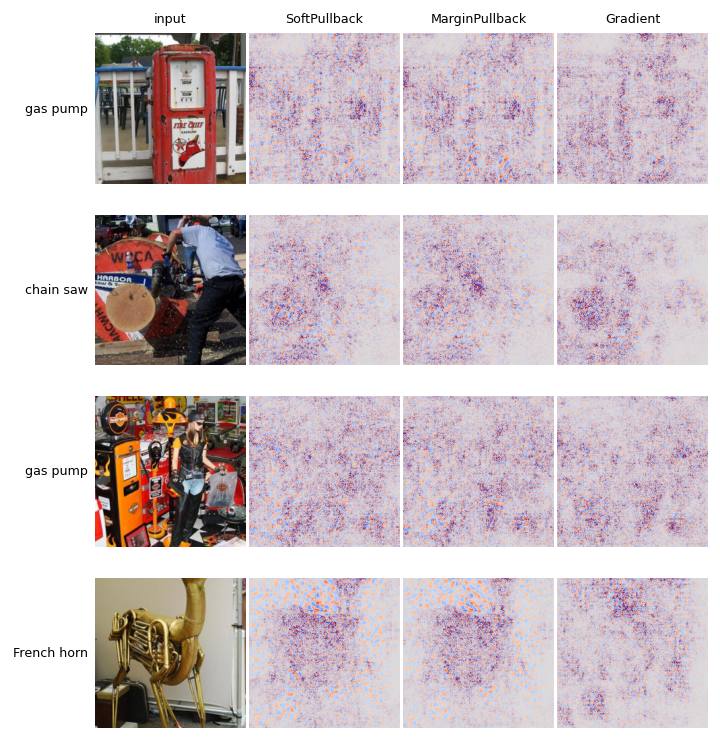

In [4]:
from spx.dossier import attributions_for

A = attributions_for(bundle, X, Y, {
    'SoftPullback': {},
    'MarginPullback': {'k': 8, 'tau_m': float('inf')},
    'Gradient': {},
})
show_maps(X, A, titles=titles)
plt.show()

## The number

`FaithfulnessEstimate`: correlation between the attribution and the drop in
score as you remove pixels. Higher better.

In [5]:
tab = summary_table('resnet50', 200)
tab[['FaithfulnessEstimate', 'RandomLogit', 'MaxSensitivity']] \
   .sort_values('FaithfulnessEstimate', ascending=False).head(6).round(4)

metric,FaithfulnessEstimate,RandomLogit,MaxSensitivity
method,,,
MarginAscent,0.686,0.022,1.052
MarginAscentFrozen,0.645,0.029,1.038
PullbackAscent,0.629,0.011,1.054
MarginGradientAscent,0.585,0.014,1.273
MarginPullback,0.557,0.084,0.410
GradientAscent,0.546,0.011,1.282


Best of all 19 methods (0.686 vs 0.629 for the paper's own Pullback Ascent).
The cost is `RandomLogit` 0.084 less target-specific, which is the mirror
image of the Fisher-Rao result and makes sense: the rival term is largely shared
between classes.

## Where it fails

Push an image *toward* a class it isn't, and the margin selector is bad at
arriving: mean `p(target)` ends at 0.39 against 0.80 for the paper's plain
one-hot ascent.

The reason is in the functional: `m_c = z_c - tau_m*LSE(rivals)` is maximised
just as well by pushing the rivals **down** as by pushing `z_c` **up**, and the
probability the rivals give up can land anywhere.

So the two selectors answer different questions "away from what this is"
vs "towards this specific class" and for counterfactuals the one-hot
selector is the right default.

gas pump -> parachute


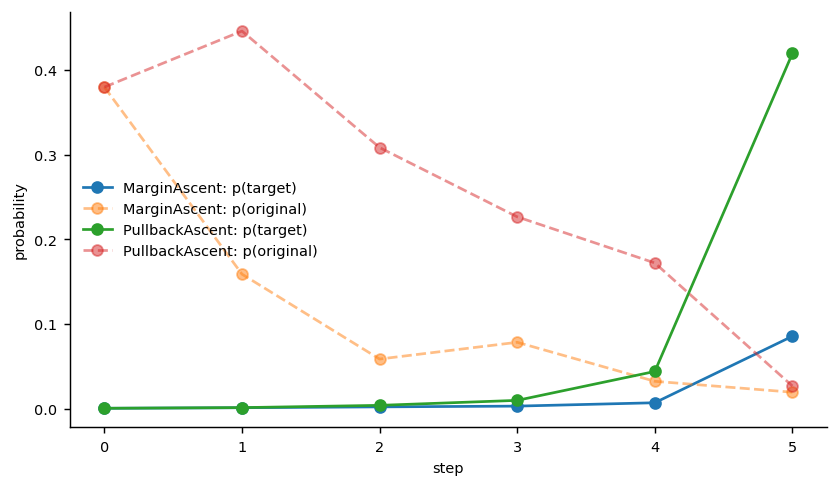

In [6]:
from spx.data import IMAGENETTE_WNIDS
from spx.explainers import MarginAscent, PullbackAscent, ascent_path

img, true_c = X[:1], Y[:1]
with torch.no_grad():
    p0 = bundle.hard(img).softmax(-1)[0]

cand = torch.tensor([c for _, c, _ in IMAGENETTE_WNIDS], device=device)
cand = cand[cand != true_c[0]]
target = cand[p0[cand].argmax()].view(1)   # strongest rival
print(f'{IMAGENETTE_NAMES[int(true_c)]} -> {IMAGENETTE_NAMES[int(target)]}')

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for name, E in [('MarginAscent', MarginAscent(bundle, k=8, alpha=20.0, steps=5)),
                ('PullbackAscent', PullbackAscent(bundle, alpha=20.0, steps=5))]:
    path = ascent_path(E, img, target)
    with torch.no_grad():
        P = torch.stack([bundle.hard(s).softmax(-1)[0] for s in path])
    ax.plot(P[:, int(target)].cpu(), 'o-', label=f'{name}: p(target)')
    ax.plot(P[:, int(true_c)].cpu(), 'o--', alpha=.5, label=f'{name}: p(original)')
ax.set_xlabel('step'); ax.set_ylabel('probability'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()